# 📊 Bank Marketing Term Deposit Prediction – Model Optimization & Comparison

## Problem Statement

Banks run marketing campaigns to promote term deposits. However, contacting every customer is expensive and inefficient.

A predictive system can help identify customers who are more likely to subscribe, allowing banks to focus marketing efforts on high-potential customers.

## Objective

The objective of this project is to improve prediction performance by training and comparing multiple machine learning models.

Tasks:
- Train Logistic Regression, Random Forest, and XGBoost models
- Apply hyperparameter tuning
- Evaluate models using multiple metrics
- Compare performance using tables and charts
- Select the best performing model

# STEP 1: Import Required Libraries

In [12]:
# Import essential libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Libraries imported successfully")
# -------------------------------
# Ignore Warnings
# -------------------------------
import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

print("✅ All warnings will be suppressed")

Libraries imported successfully
✅ All warnings will be suppressed


# STEP 2: Load Dataset

In [27]:
# ===============================
#  Load Dataset
# ===============================

# Load dataset (bank marketing dataset uses ';' as separator)
df = pd.read_csv("bank.csv", sep=';')

# Print dataset shape
print("Dataset Shape:", df.shape)

# Display first 5 rows
df.head()

Dataset Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# STEP 3: Data Cleaning

In [14]:
# ===============================
#  Data Cleaning
# ===============================

# Check for missing values
print("Missing Values in Dataset:\n")
print(df.isnull().sum())

# Check for duplicate rows
duplicates = df.duplicated().sum()

# Print duplicate count
print("\nNumber of Duplicate Rows:", duplicates)

# Remove duplicates
df = df.drop_duplicates()

# Print new dataset shape
print("Dataset Shape After Removing Duplicates:", df.shape)

Missing Values in Dataset:

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Number of Duplicate Rows: 12
Dataset Shape After Removing Duplicates: (41176, 21)


# STEP 4: Encode Target Variable

In [15]:
# ===============================
#  Encode Target Variable
# ===============================

# Convert target column 'y' into numeric values
# yes -> 1
# no -> 0
df['y'] = df['y'].map({'yes':1, 'no':0})

# Print target distribution
print("Target Variable Distribution:\n")
print(df['y'].value_counts())

Target Variable Distribution:

y
0    36537
1     4639
Name: count, dtype: int64


# STEP 5: Split Features and Target

In [16]:
# ===============================
#  Split Features and Target
# ===============================

# Separate features and target variable
X = df.drop('y', axis=1)
y = df['y']

# Print shapes
print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape:", y.shape)

Feature Matrix Shape: (41176, 20)
Target Vector Shape: (41176,)


# STEP 6: Identify Categorical and Numerical Columns

In [17]:
# ===============================
#  Identify Categorical and Numerical Columns
# ===============================

# Select categorical columns
cat_cols = X.select_dtypes(include='object').columns

# Select numerical columns
num_cols = X.select_dtypes(exclude='object').columns

# Print columns
print("Categorical Columns:")
print(list(cat_cols))

print("\nNumerical Columns:")
print(list(num_cols))

Categorical Columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Numerical Columns:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


# STEP 7: Train-Test Split

In [18]:
# ===============================
#  Train-Test Split
# ===============================

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Print dataset shapes
print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (32940, 20)
Testing Set Shape: (8236, 20)


# STEP 8: Create Preprocessing Pipeline

In [19]:
# ===============================
#  Create Preprocessing Pipeline
# ===============================

# Apply OneHotEncoding for categorical columns
# Apply StandardScaler for numerical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

# Print confirmation
print("Preprocessing pipeline created successfully")

Preprocessing pipeline created successfully


# STEP 9: Logistic Regression with Hyperparameter Tuning

In [20]:
# ===============================
#  Logistic Regression with Hyperparameter Tuning
# ===============================

# Create pipeline
log_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=2000))
])

# Hyperparameters
log_params = {
    'model__C':[0.01,0.1,1,10]
}

# RandomizedSearchCV
log_search = RandomizedSearchCV(
    log_pipeline,
    log_params,
    cv=5,
    scoring='roc_auc',
    n_iter=4,
    random_state=42
)

# Train model
log_search.fit(X_train, y_train)

# Best model
best_log_model = log_search.best_estimator_

# Print best parameters
print("Best Logistic Regression Parameters:")
print(log_search.best_params_)

Best Logistic Regression Parameters:
{'model__C': 1}


# STEP 10: Random Forest with Hyperparameter Tuning

In [21]:
# ===============================
#  Random Forest with Hyperparameter Tuning
# ===============================

rf_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier())
])

rf_params = {
    'model__n_estimators':[100,200],
    'model__max_depth':[None,10,20]
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring='roc_auc',
    n_iter=4,
    random_state=42
)

rf_search.fit(X_train, y_train)

best_rf_model = rf_search.best_estimator_

print("Best Random Forest Parameters:")
print(rf_search.best_params_)

Best Random Forest Parameters:
{'model__n_estimators': 200, 'model__max_depth': 20}


# STEP 11: XGBoost with Hyperparameter Tuning

In [22]:
# ===============================
#  XGBoost with Hyperparameter Tuning
# ===============================

xgb_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', XGBClassifier(
        eval_metric='logloss',
        use_label_encoder=False
    ))
])

xgb_params = {
    'model__n_estimators':[100,200],
    'model__max_depth':[3,6],
    'model__learning_rate':[0.01,0.1]
}

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    xgb_params,
    cv=5,
    scoring='roc_auc',
    n_iter=4,
    random_state=42
)

xgb_search.fit(X_train, y_train)

best_xgb_model = xgb_search.best_estimator_

print("Best XGBoost Parameters:")
print(xgb_search.best_params_)

Best XGBoost Parameters:
{'model__n_estimators': 200, 'model__max_depth': 6, 'model__learning_rate': 0.1}


# STEP 12: Create Model Evaluation Function

In [25]:
# ===============================
#  Create Model Evaluation Function
# ===============================

def evaluate_model(model):

    # Predict labels
    y_pred = model.predict(X_test)

    # Predict probabilities
    y_prob = model.predict_proba(X_test)[:,1]

    # Calculate metrics
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    roc = roc_auc_score(y_test,y_prob)

    # Return metrics
    return accuracy,precision,recall,f1,roc

# STEP 13: Evaluate and Compare Models

In [24]:
# ===============================
#  Evaluate and Compare Models
# ===============================

results = []

models = {
    "Logistic Regression":best_log_model,
    "Random Forest":best_rf_model,
    "XGBoost":best_xgb_model
}

for name,model in models.items():

    acc,prec,rec,f1,roc = evaluate_model(model)

    results.append([name,acc,prec,rec,f1,roc])

results_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy","Precision","Recall","F1 Score","ROC-AUC"]
)

print("Model Comparison Table:\n")
print(results_df)

Model Comparison Table:

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.908936   0.647351  0.421336  0.510444  0.938935
1        Random Forest  0.913793   0.656609  0.492457  0.562808  0.947600
2              XGBoost  0.913793   0.637280  0.545259  0.587689  0.949757


# STEP 14:  Model Comparison Chart

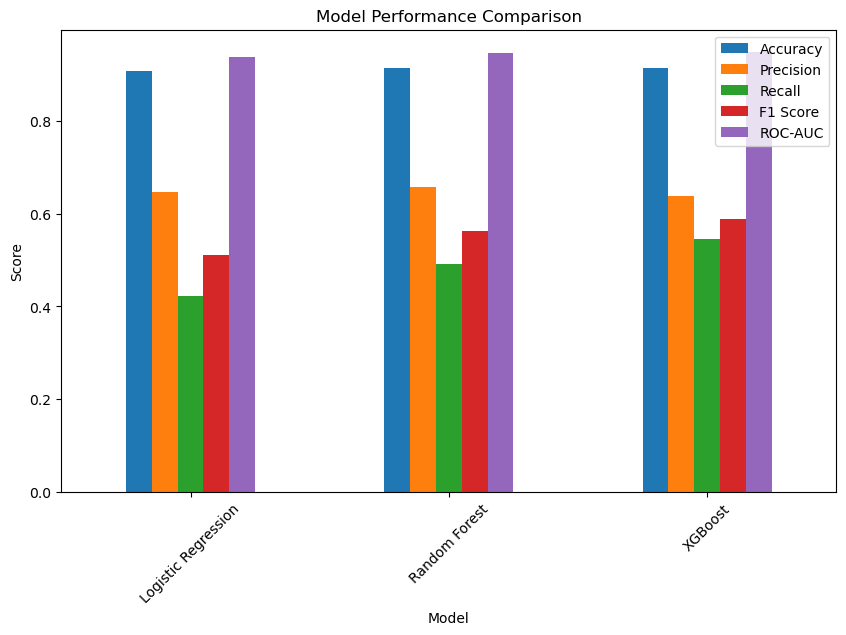

In [26]:
# ===============================
#  Plot Model Comparison Chart
# ===============================

results_df.set_index("Model").plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)

plt.show()

# Best Model Selection and Conclusion

After evaluating all models using Accuracy, Precision, Recall, F1-Score, and ROC-AUC, the **XGBoost model is selected as the best performing model**.

## Model Performance Summary

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|------|------|------|------|------|------|
| Logistic Regression | 0.9089 | 0.6473 | 0.4213 | 0.5104 | 0.9389 |
| Random Forest | 0.9138 | 0.6566 | 0.4925 | 0.5628 | 0.9476 |
| XGBoost | 0.9138 | 0.6373 | 0.5453 | 0.5877 | **0.9498** |

## Why XGBoost Was Selected

The XGBoost model achieved the **highest ROC-AUC score (0.9497)**, indicating the best ability to distinguish between customers who will subscribe to a term deposit and those who will not.

In addition, XGBoost achieved the **highest Recall and F1-score**, meaning it identifies more potential subscribers while maintaining balanced overall performance.

Since the dataset is **imbalanced**, ROC-AUC and Recall are more reliable metrics than accuracy alone. Based on these results, **XGBoost provides the most effective predictive performance** for this task.

## Final Conclusion

This project demonstrates how training multiple machine learning models and applying hyperparameter tuning can significantly improve prediction performance. By comparing models using multiple evaluation metrics, XGBoost was identified as the most suitable model for predicting customer subscription to term deposits. This approach enables banks to target marketing campaigns more efficiently and focus on customers with the highest likelihood of conversion.